In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [27]:
from pathlib import Path

import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = 2

def print_comparison_table(rows):
    columns = [
        "Policy",
        "Episodes",
        "Mean total reward",
        "Mean local queue",
        "Total completed steps",
        "Mean switches / episode",
    ]

    def format_value(value):
        if isinstance(value, float):
            return f"{value:.3f}"
        return str(value)

    widths = {column: len(column) for column in columns}
    for row in rows:
        for column in columns:
            widths[column] = max(widths[column], len(format_value(row.get(column, ""))))

    header = " | ".join(column.ljust(widths[column]) for column in columns)
    separator = "-+-".join("-" * widths[column] for column in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(format_value(row.get(column, "")).ljust(widths[column]) for column in columns))


In [3]:
from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions


In [28]:
#Constant parameters for the simulation and training
SIMULATION_DURATION = 3600
NUM_EPISODES = 20
EVALUATION_EPISODES = 10
TOTAL_TIMESTEPS = 150_000


## 1. Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first when you want a different learning problem.


In [29]:
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=2000,
    trip_period=0.5,
    seed=42,
)

paths = generator.generate_all()
print("Generated:", paths.config_file)
print("Traffic-light agents:", traffic_light_ids)


Success.
calling /usr/share/sumo/bin/duarouter -n /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/network.net.xml -r /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/trips.trips.xml --ignore-errors --begin 0 --end 2000 --no-step-log --no-warnings -o /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/routes.rou.xml
Success.
Generated: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/config.sumocfg
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## 2. Run the simple baselines

Random and fixed-time are useful sanity checks before training. They use the same environment and the same evaluation seeds as the learned policies.


In [30]:
random_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=random_actions,
    episodes=NUM_EPISODES,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

fixed_time_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=fixed_time_actions,
    episodes=NUM_EPISODES,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

baseline_rows = [
    {
        "Policy": "Random",
        "Episodes": random_result["episodes"],
        "Mean total reward": random_result["mean_total_reward"],
        "Mean local queue": random_result["mean_local_queue"],
        "Total completed steps": random_result["total_completed_steps"],
        "Mean switches / episode": random_result["mean_switches_per_episode"],
    },
    {
        "Policy": "Fixed time",
        "Episodes": fixed_time_result["episodes"],
        "Mean total reward": fixed_time_result["mean_total_reward"],
        "Mean local queue": fixed_time_result["mean_local_queue"],
        "Total completed steps": fixed_time_result["total_completed_steps"],
        "Mean switches / episode": fixed_time_result["mean_switches_per_episode"],
    },
]

print_comparison_table(baseline_rows)


 Retrying in 1 seconds
Step #12760.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 4000 ACT 0 BUF 0)                tep #4500.00 (9ms ~= 111.11*RT, ~74777.78UPS, TraCI: 8ms, vehicles TOT 3337 ACT 673 BUF 6ep #9000.00 (3ms ~= 333.33*RT, ~69666.67UPS, TraCI: 9ms, vehicles TOT 3779 ACT 209 BUF 2
 Retrying in 1 seconds
Step #2100.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 4000 ACT 0 BUF 0)                 
 Retrying in 1 seconds
Step #4260.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 4000 ACT 0 BUF 0)                 
 Retrying in 1 seconds
Step #9495.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 4000 ACT 0 BUF 0)                 tep #4500.00 (6ms ~= 166.67*RT, ~78333.33UPS, TraCI: 8ms, vehicles TOT 3712 ACT 470 BUF 2ep #9000.00 (0ms ?*RT. ?UPS, TraCI: 11ms, vehicles TOT 3989 ACT 45 BUF 11)              
 Retrying in 1 seconds
Step #18000.00 (0ms ?*RT. ?UPS, TraCI: 9ms, vehicles TOT 3938 ACT 61 BUF 62)              tep #4500.00 (13ms ~= 76.92*RT, ~69615.38UPS, TraCI: 10ms, vehicles TOT 2252 

## 3. Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.


 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 14ms, vehicles TOT 0 ACT 0 BUF 0)                     
 Retrying in 1 seconds
Step #13070.00 (0ms ?*RT. ?UPS, TraCI: 7ms, vehicles TOT 4000 ACT 0 BUF 0)                tep #4500.00 (7ms ~= 142.86*RT, ~101142.86UPS, TraCI: 9ms, vehicles TOT 3294 ACT 708 BUF ep #9000.00 (2ms ~= 500.00*RT, ~88500.00UPS, TraCI: 11ms, vehicles TOT 3785 ACT 177 BUF 
 Retrying in 1 seconds
Step #17395.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 4000 ACT 0 BUF 0)                tep #4500.00 (15ms ~= 66.67*RT, ~57600.00UPS, TraCI: 16ms, vehicles TOT 2403 ACT 864 BUF ep #9000.00 (7ms ~= 142.86*RT, ~80857.14UPS, TraCI: 11ms, vehicles TOT 3006 ACT 566 BUF p #13500.00 (4ms ~= 250.00*RT, ~53250.00UPS, TraCI: 10ms, vehicles TOT 3601 ACT 213 BUF
 Retrying in 1 seconds
Step #17295.00 (0ms ?*RT. ?UPS, TraCI: 8ms, vehicles TOT 4000 ACT 0 BUF 0)                tep #4500.00 (18ms ~= 55.56*RT, ~46555.56UPS, TraCI: 14ms, vehicles TOT 2592 ACT 838 BUF ep #9000.00 (7ms

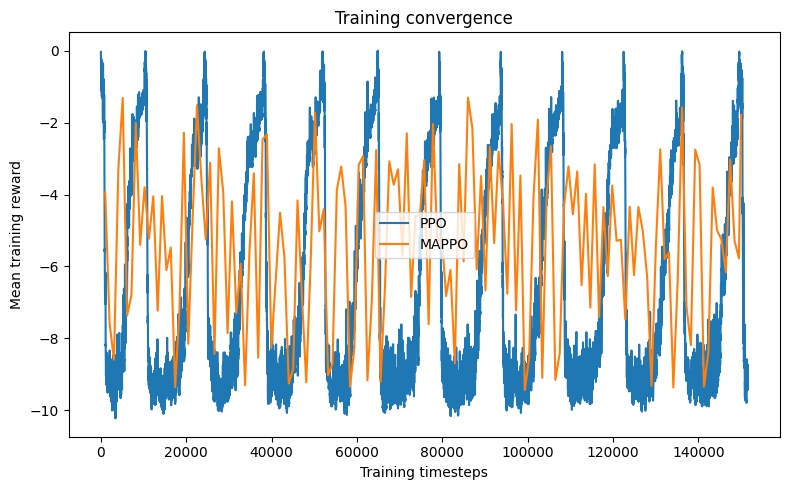

Saved PPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/ppo_sumo_traffic.zip
Saved MAPPO model: /home/isaac/Uni-Masters/MARL-TSC Group/marl-tsc/outputs/models/mappo.pt


In [33]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=150_000,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=150_000,
    rollout_steps=1024,
    max_steps=SIMULATION_DURATION,
    seed=42,
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

fig, ax = plot_training_histories(ppo_history + mappo_history)
plt.show()

print("Saved PPO model:", ppo_model_path)
print("Saved MAPPO model:", mappo_model_path)


## 4. Evaluate all policies on the same seeds

The final comparison table keeps the baseline runs and adds the shared PPO and MAPPO policies on the same evaluation seeds.


In [41]:
shared_ppo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=ppo_model,
    episodes=NUM_EPISODES,
    max_steps=SIMULATION_DURATION,
    seed=42, 
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

shared_mappo_result = evaluate_policy(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=mappo_model,
    episodes=NUM_EPISODES,
    max_steps=SIMULATION_DURATION,
    seed=42, 
    env_kwargs={"green_phase_count": GREEN_PHASE_COUNT,
                "min_green_seconds": 5 },
)

comparison_rows = baseline_rows + [
    {
        "Policy": "Shared PPO",
        "Episodes": shared_ppo_result["episodes"],
        "Mean total reward": shared_ppo_result["mean_total_reward"],
        "Mean local queue": shared_ppo_result["mean_local_queue"],
        "Total completed steps": shared_ppo_result["total_completed_steps"],
        "Mean switches / episode": shared_ppo_result["mean_switches_per_episode"],
    },
    {
        "Policy": "MAPPO",
        "Episodes": shared_mappo_result["episodes"],
        "Mean total reward": shared_mappo_result["mean_total_reward"],
        "Mean local queue": shared_mappo_result["mean_local_queue"],
        "Total completed steps": shared_mappo_result["total_completed_steps"],
        "Mean switches / episode": shared_mappo_result["mean_switches_per_episode"],
    },
]

print_comparison_table(comparison_rows)


TraCIException: Connection 'default' is already active.

In [40]:
import traci

try:
    traci.close()
except Exception:
    pass